In [2]:
# Load Parquet (County Regression Data), preview, list columns, and show descriptives

from pathlib import Path
import pandas as pd

# --- PATH ---
pq_path = Path('/Users/mickeynguyen/Documents/School /Fracking Paper/Data and Code/Parquet of Data/BLS_IRS_fossil_working.parquet')

# --- LOAD ---
df = pd.read_parquet(pq_path)
print(f"Loaded: {pq_path.name}  |  Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")


Loaded: BLS_IRS_fossil_working.parquet  |  Shape: 275,968 rows × 54 columns


In [3]:
import pandas as pd, numpy as np

# --- Config ---
PATH = "/Users/mickeynguyen/Documents/School /Fracking Paper/Data and Code/Parquet of Data/BLS_IRS_fossil_working.parquet"
WINDOW = (2005, 2012)  # IRS-aligned window
vars_county = ["newvalue_capita", "d_wages_capita", "d_irswages_capita", "d_irsotherinc_capita", "d_irsagi_capita"]

# --- Load & window ---
df = pd.read_parquet(PATH)
df["year"] = df["year"].astype(int)
df_use = df[df["year"].between(WINDOW[0], WINDOW[1])].copy()


# --- Enforce balanced panel over WINDOW ---
years = sorted(df_use["year"].unique().tolist())
ny = df_use.drop_duplicates(subset=["fips","year"]).groupby("fips")["year"].nunique()
balanced_fips = ny.index[ny == len(years)]
df_bal = df_use[df_use["fips"].isin(balanced_fips)]

# --- Reduce to one row per county-year for target vars ---
present = [v for v in vars_county if v in df_bal.columns]
df_stat = (
    df_bal[["fips","year"] + present]
      .drop_duplicates(subset=["fips","year"])
      .sort_values(["fips","year"])
)

# --- Summarize ---
def summarize(df_in, cols):
    rows = []
    for c in cols:
        s = df_in[c].astype(float)
        rows.append({
            "variable": c,
            "N": int(s.count()),
            "Mean": s.mean(),
            "SD": s.std(ddof=1),
            "P25": s.quantile(0.25),
            "Median": s.quantile(0.50),
            "P75": s.quantile(0.75),
            "Min": s.min(),
            "Max": s.max(),
        })
    return pd.DataFrame(rows).set_index("variable")

summary = summarize(df_stat, present)
summary_rounded = summary.copy()
for col in ["Mean","SD","P25","Median","P75","Min","Max"]:
    summary_rounded[col] = summary_rounded[col].round(3)

print(f"Years in balanced panel: {years[0]}–{years[-1]} (T={len(years)})")
print(f"Counties in balanced panel: {df_stat['fips'].nunique():,}")
print(f"County–years (after filters): {len(df_stat):,}")
summary_rounded
# Optional: save
# summary_rounded.to_csv("A2_summary_stats_county.csv")

Years in balanced panel: 2005–2012 (T=8)
Counties in balanced panel: 3,136
County–years (after filters): 25,088


,N,Mean,SD,P25,Median,P75,Min,Max
variable,,,,,,,,
newvalue_capita,25088,0.005,0.145,0.000,0.000,0.000,-0.000,17.300
d_wages_capita,25088,271.339,2657.484,-717.298,137.976,1049.387,-36281.625,71280.070
d_irswages_capita,25088,453.417,2575.478,-673.067,272.993,1387.879,-114996.148,107233.758
d_irsotherinc_capita,25088,1033.476,6694.700,-551.278,658.064,2179.430,-343888.844,316529.969
d_irsagi_capita,25088,1440.622,7301.039,-1310.912,1106.430,3562.692,-244675.672,258477.359


Observations: 25,088
Share with positive newvalue_capita: 25.23%
Median=0, P75=6.74958e-08, P90=0.00101014, P99=0.056037 (Millions USD per person)


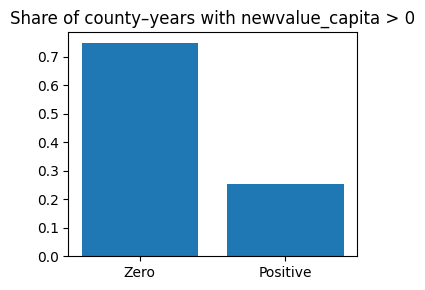

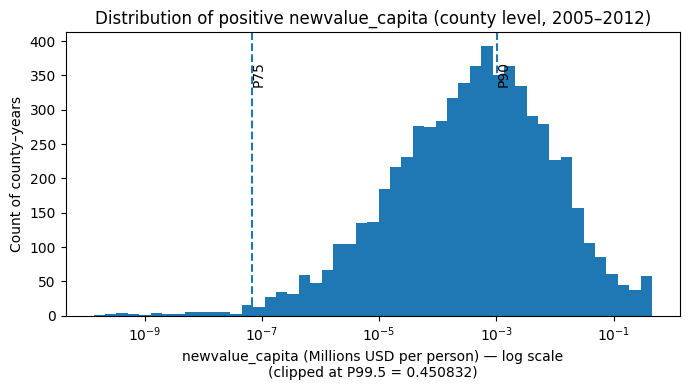

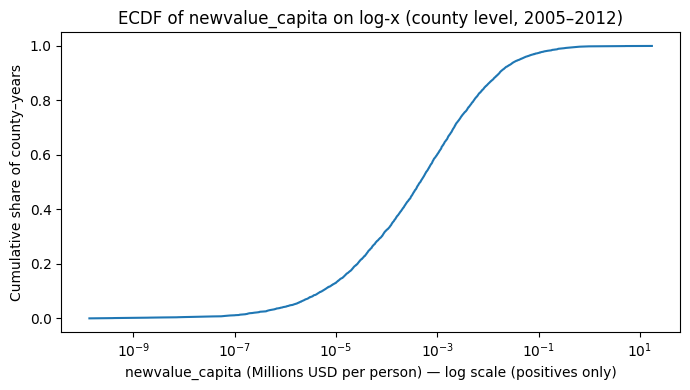

In [4]:
# Visuals for the county-level shock: newvalue_capita
# (1) Histogram (clipped to P99 so the tail doesn't swamp the view)
# (2) ECDF with log-x for positive values only

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_bal2 = (
    df_bal[["fips","year"] + present]
      .drop_duplicates(subset=["fips","year"])
      .sort_values(["fips","year"])
)

# ---- 0) Choose the DataFrame ----
X = df_bal2["newvalue_capita"].astype(float)   # swap df_bal -> df_use/df if needed

# ---- 1) Optional: convert to $ per person if your file stores "millions per person" ----
# If typical values look like 0.0008, that's likely "millions per person".
SCALE_TO_DOLLARS = False  # set True if you want $/person on axes instead of millions/person
x = X * 1_000_000 if SCALE_TO_DOLLARS else X

unit_label = "USD per person" if SCALE_TO_DOLLARS else "Millions USD per person"

# ---- 2) Basic cleaning & diagnostics ----
x = x.replace([np.inf, -np.inf], np.nan).dropna()
x_pos = x[x > 0]  # for log-x ECDF, zeros can't be shown
share_pos = (x_pos.size / x.size) if x.size else np.nan
p50, p75, p90, p99 = np.nanpercentile(x, [50, 75, 90, 99])

print(f"Observations: {x.size:,}")
print(f"Share with positive newvalue_capita: {share_pos:.2%}")
print(f"Median={p50:.6g}, P75={p75:.6g}, P90={p90:.6g}, P99={p99:.6g} ({unit_label})")

# BAR
plt.figure(figsize=(3.5,3))
plt.bar(["Zero","Positive"], [1-share_pos, share_pos])
plt.title("Share of county–years with newvalue_capita > 0")
plt.tight_layout(); plt.show()

# ---- 3) Histogram (clip extreme right tail at P99 for readability) ----
clip_hi = np.nanpercentile(x_pos, 99.5)   # was 99; go a bit tighter
min_pos = x_pos[x_pos > 0].min()
bins = np.logspace(np.log10(min_pos), np.log10(clip_hi), 50)

plt.figure(figsize=(7,4))
plt.hist(x_pos.clip(upper=clip_hi), bins=bins)
plt.xscale("log")
plt.xlabel(f"newvalue_capita ({unit_label}) — log scale\n(clipped at P99.5 = {clip_hi:.6g})")
plt.ylabel("Count of county–years")
plt.title("Distribution of positive newvalue_capita (county level, 2005–2012)")
for q, lab in [(p50,"P50"), (p75,"P75"), (p90,"P90")]:
    if q>0: plt.axvline(q, linestyle="--"); plt.text(q, plt.ylim()[1]*0.9, lab, rotation=90, va="top")
plt.tight_layout(); plt.show()

# ---- 4) ECDF with log-x (positives only) ----
if x_pos.size > 0:
    xs = np.sort(x_pos.values)
    ys = np.arange(1, xs.size + 1) / xs.size

    plt.figure(figsize=(7,4))
    plt.plot(xs, ys, marker="", linestyle="-")
    plt.xscale("log")
    plt.xlabel(f"newvalue_capita ({unit_label}) — log scale (positives only)")
    plt.ylabel("Cumulative share of county–years")
    plt.title("ECDF of newvalue_capita on log-x (county level, 2005–2012)")
    plt.tight_layout()
    plt.show()
else:
    print("No positive values found for newvalue_capita; ECDF on log-x not shown.")

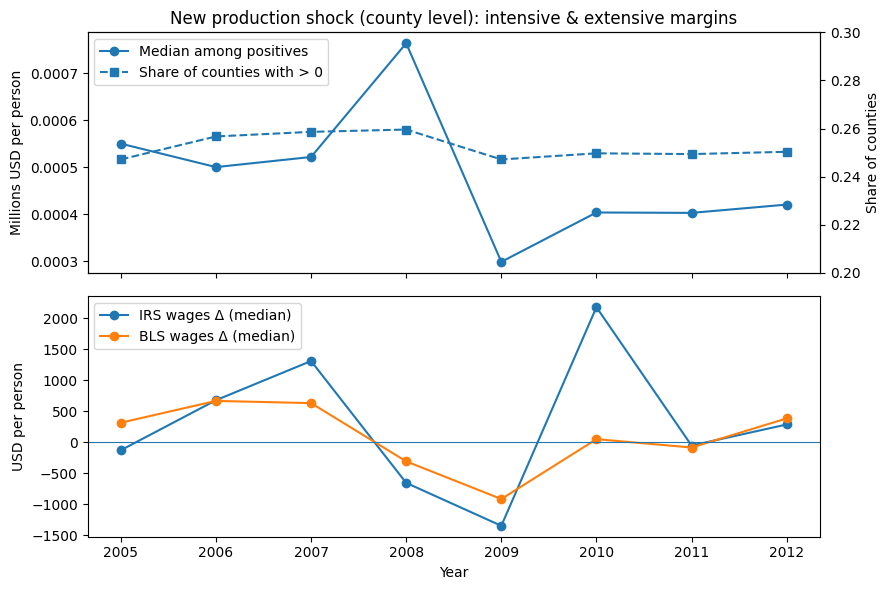

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- data slice (balanced, All industries) ---
cols = ["year", "newvalue_capita", "d_irswages_capita", "d_wages_capita"]
dat = df_bal2[cols].copy()
for c in ["newvalue_capita", "d_irswages_capita", "d_wages_capita"]:
    dat[c] = pd.to_numeric(dat[c], errors="coerce")

# --- shock: extensive vs. intensive margins by year ---
share_pos   = dat.groupby("year")["newvalue_capita"].apply(lambda s: (s > 0).mean())
cond_median = dat.loc[dat["newvalue_capita"] > 0].groupby("year")["newvalue_capita"].median()  # Millions USD / person

# --- outcomes: medians by year ---
med_irs = dat.groupby("year")["d_irswages_capita"].median()   # USD / person
med_bls = dat.groupby("year")["d_wages_capita"].median()      # USD / person

# --- plot: two panels ---
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Top: shock (intensive + extensive)
ax1 = axes[0]
ln1 = ax1.plot(cond_median.index, cond_median.values, marker="o", label="Median among positives")
ax1.set_ylabel("Millions USD per person")
ax1.set_title("New production shock (county level): intensive & extensive margins")

ax2 = ax1.twinx()
ln2 = ax2.plot(share_pos.index, share_pos.values, linestyle="--", marker="s", label="Share of counties with > 0")
ax2.set_ylabel("Share of counties")
ax2.set_ylim(.20,.30)


# one legend for both axes
lines  = ln1 + ln2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

# Bottom: outcomes (medians)
axes[1].plot(med_irs.index, med_irs.values, marker="o", label="IRS wages Δ (median)")
axes[1].plot(med_bls.index, med_bls.values, marker="o", label="BLS wages Δ (median)")
axes[1].axhline(0, linewidth=0.8)
axes[1].set_ylabel("USD per person")
axes[1].set_xlabel("Year")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

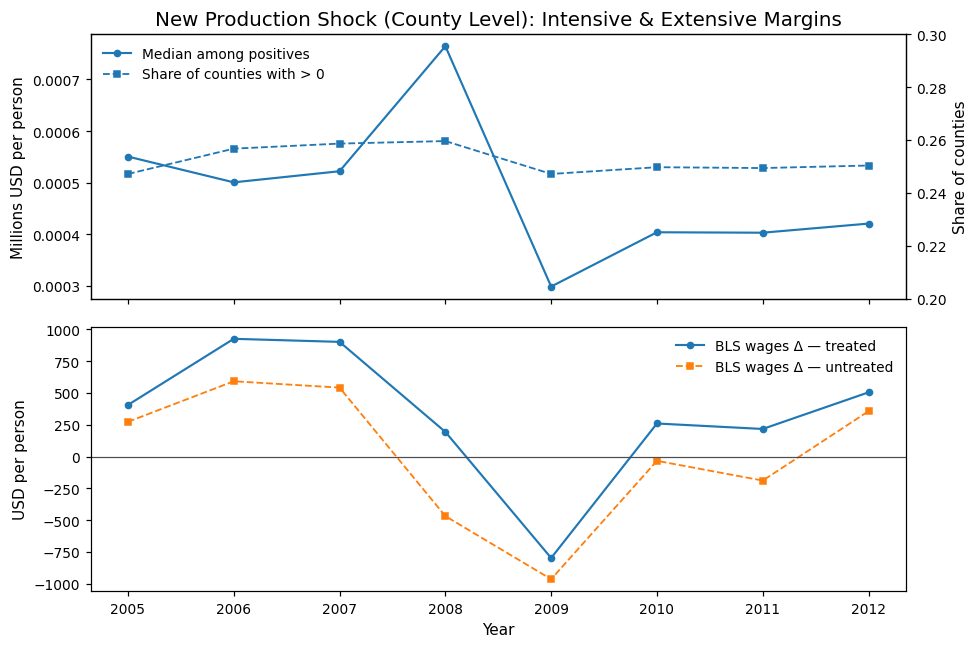

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- data slice (balanced, All industries) ---
cols = ["fips", "year", "newvalue_capita", "d_wages_capita"]
dat = df_bal2[cols].copy()
for c in ["newvalue_capita", "d_wages_capita"]:
    dat[c] = pd.to_numeric(dat[c], errors="coerce")

# --- county-level treatment flag: any new production in window ---
treated_flag = dat.groupby("fips")["newvalue_capita"].apply(lambda s: (s > 0).any())
dat["treated"] = dat["fips"].map(treated_flag)

# --- shock: extensive vs. intensive margins by year ---
share_pos   = dat.groupby("year")["newvalue_capita"].apply(lambda s: (s > 0).mean())
cond_median = dat.loc[dat["newvalue_capita"] > 0].groupby("year")["newvalue_capita"].median()  # Millions USD / person

# --- outcomes: BLS wage medians by year (treated vs untreated) ---
med_bls_treated   = dat.loc[dat["treated"]].groupby("year")["d_wages_capita"].median()
med_bls_untreated = dat.loc[~dat["treated"]].groupby("year")["d_wages_capita"].median()

# --- plot (match prior styling) ---
with plt.rc_context({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
}):
    fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

    # Top: shock (intensive + extensive)
    ax1 = axes[0]
    ln1 = ax1.plot(cond_median.index, cond_median.values,
                   marker="o", markersize=4, linewidth=1.4, label="Median among positives")
    ax1.set_ylabel("Millions USD per person")
    ax1.set_title("New Production Shock (County Level): Intensive & Extensive Margins")

    ax2 = ax1.twinx()
    ln2 = ax2.plot(share_pos.index, share_pos.values,
                   linestyle="--", marker="s", markersize=4, linewidth=1.2,
                   label="Share of counties with > 0")
    ax2.set_ylabel("Share of counties")
    ax2.set_ylim(0.20, 0.30)
    ax2.set_yticks(np.linspace(0.20, 0.30, 6))

    lines = ln1 + ln2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="upper left", frameon=False)

    # Bottom: BLS wages Δ (treated vs untreated)
    axb = axes[1]
    axb.plot(med_bls_treated.index,   med_bls_treated.values,
             marker="o", markersize=4, linewidth=1.4, label="BLS wages Δ — treated")
    axb.plot(med_bls_untreated.index, med_bls_untreated.values,
             linestyle="--", marker="s", markersize=4, linewidth=1.2, label="BLS wages Δ — untreated")
    axb.axhline(0, color="0.3", linewidth=0.8)
    axb.set_ylabel("USD per person")
    axb.set_xlabel("Year")
    axb.set_xticks(range(2005, 2013))
    axb.legend(loc="upper right", frameon=False)

    plt.tight_layout()
    plt.show()

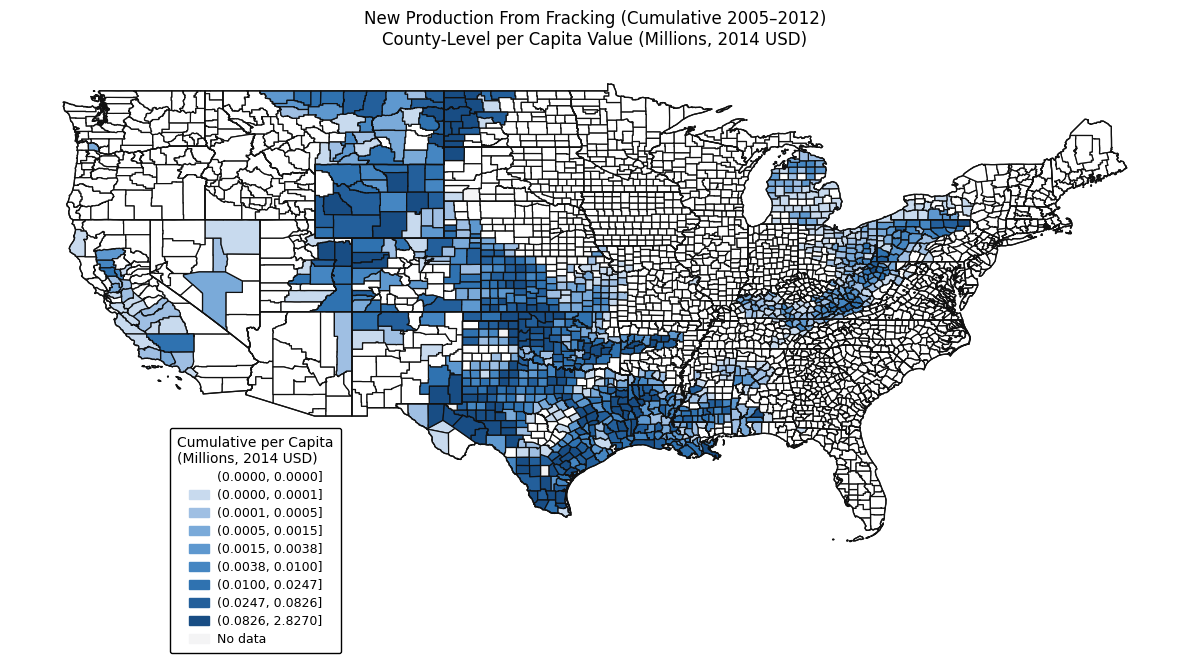

In [7]:
# Figure 2 — Cumulative new production per capita, 2004–2012 (Millions USD per person)
# Requires: geopandas, shapely, pyproj, pyogrio, rtree

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype
import matplotlib.patches as mpatches

# ------------------------------------------------------------
# 0) Paths
# ------------------------------------------------------------
PARQUET_PATH = "/Users/mickeynguyen/Documents/School /Fracking Paper/Data and Code/Parquet of Data/BLS_IRS_fossil_working.parquet"
COUNTY_SHP   = "/Users/mickeynguyen/Documents/School /Fracking Paper/Data and Code/cb_2018_us_county_5m/cb_2018_us_county_5m.shp"

# ------------------------------------------------------------
# 1) Load county panel and build cumulative new production (2004–2012)
#    Keep one value per county–year (avoid double-counting across rows),
#    then sum across years. Units remain Millions USD per person.
# ------------------------------------------------------------
df = pd.read_parquet(PARQUET_PATH)

df_win = df.loc[df["year"].between(2005, 2012), ["fips", "year", "newvalue_capita"]].copy() 
df_win["newvalue_capita"] = pd.to_numeric(df_win["newvalue_capita"], errors="coerce")

one_per_cy = (
    df_win
    .dropna(subset=["newvalue_capita"])
    .drop_duplicates(subset=["fips", "year"])
) 

cum = (
    one_per_cy.groupby("fips", as_index=False)["newvalue_capita"]
    .sum()
    .rename(columns={"newvalue_capita": "cum_newvalue_capita_mil"})
)
cum["fips5"] = cum["fips"].astype(str).str.zfill(5)

# ------------------------------------------------------------
# 2) Read geometries (contiguos-48 + DC) and merge cumulative values
# ------------------------------------------------------------
g = gpd.read_file(COUNTY_SHP)

# Drop AK (02), HI (15), PR (72), and territories (60, 66, 69, 78)
DROP_STATES = {"02", "15", "72", "60", "66", "69", "78"}
g = g[~g["STATEFP"].isin(DROP_STATES)].copy()

g["GEOID"] = g["GEOID"].astype(str)
g = g.merge(cum[["fips5", "cum_newvalue_capita_mil"]], left_on="GEOID", right_on="fips5", how="left")

# ------------------------------------------------------------
# 3) Classify cumulative values into the paper’s bins (Millions per person)
#    Separate exact zeros; positives into 8 bins.
# ------------------------------------------------------------
edges_pos = [0.0, 0.0001, 0.0005, 0.0015, 0.0038, 0.0100, 0.0247, 0.0826, 2.8270]
labels_pos = [
    "(0.0000, 0.0001]",
    "(0.0001, 0.0005]",
    "(0.0005, 0.0015]",
    "(0.0015, 0.0038]",
    "(0.0038, 0.0100]",
    "(0.0100, 0.0247]",
    "(0.0247, 0.0826]",
    "(0.0826, 2.8270]",
]

val = g["cum_newvalue_capita_mil"].astype(float)
is_zero = val.fillna(0).eq(0)
is_pos  = val.gt(0)

bins = pd.Series(index=g.index, dtype="object")
bins.loc[is_zero & val.notna()] = "(0.0000, 0.0000]"
bins.loc[is_pos] = pd.cut(val[is_pos], bins=edges_pos, labels=labels_pos, right=True)

ordered_cats = ["(0.0000, 0.0000]"] + labels_pos + ["No data"]
bins = bins.astype(CategoricalDtype(categories=ordered_cats, ordered=True)).fillna("No data")
g["bin"] = bins

# Colors for categories (white→dark blue; No data = light gray)
palette = {
    "No data": "#f4f4f5",
    "(0.0000, 0.0000]": "#ffffff",
    "(0.0000, 0.0001]": "#c8daee",
    "(0.0001, 0.0005]": "#9fbfe3",
    "(0.0005, 0.0015]": "#7aaad9",
    "(0.0015, 0.0038]": "#5e98cf",
    "(0.0038, 0.0100]": "#4586c2",
    "(0.0100, 0.0247]": "#2f72b0",
    "(0.0247, 0.0826]": "#235f9b",
    "(0.0826, 2.8270]": "#184d84",
}
g["__color"] = g["bin"].map(palette)

# ------------------------------------------------------------
# 4) Plot (dark matched outlines for counties and states; legend lower-left)
# ------------------------------------------------------------
# Figure and base map
fig, ax = plt.subplots(1, 1, figsize=(12, 7)) # US MAP
g.plot(ax=ax, color=g["__color"], edgecolor="#111111", linewidth=0.9, zorder=1) # Draws county outlines

# State borders on top (same dark outline)
states = g.dissolve(by="STATEFP", as_index=False)[["STATEFP", "geometry"]]
states.boundary.plot(ax=ax, edgecolor="#111111", linewidth=0.9, zorder=2) # Draws state outlines

# Axes cosmetic
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title(
    "New Production From Fracking (Cumulative 2005–2012)\n"
    "County-Level per Capita Value (Millions, 2014 USD)",
    pad=12,
)

# Legend (ordered, placed below SW USA)
legend_order = ordered_cats
handles = [mpatches.Patch(color=palette[c], label=c) for c in legend_order]

ca = g[g["STATEFP"] == "06"].total_bounds  # minx, miny, maxx, maxy
x_mid = (ca[0] + ca[2]) / 2
y_below = ca[1] - 1.5   # a little below CA (degrees; adjust as needed)

ax.legend(
    handles=handles, title="Cumulative per Capita\n(Millions, 2014 USD)",
    loc="upper left",
    bbox_to_anchor=(x_mid, y_below),
    bbox_transform=ax.transData,      # <-- interpret anchor in map coords
    frameon=True, facecolor="white", edgecolor="black", framealpha=1.0,
    fontsize=9, title_fontsize=10, borderpad=0.6, labelspacing=0.4,
    handlelength=1.6, handletextpad=0.6
)

plt.tight_layout()
plt.show()

/var/folders/jz/f_xwhp0d6b9bslqfq_83rz6m0000gn/T/ipykernel_291/649531752.py:49: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  treated_mask = g["any_production"].fillna(False)


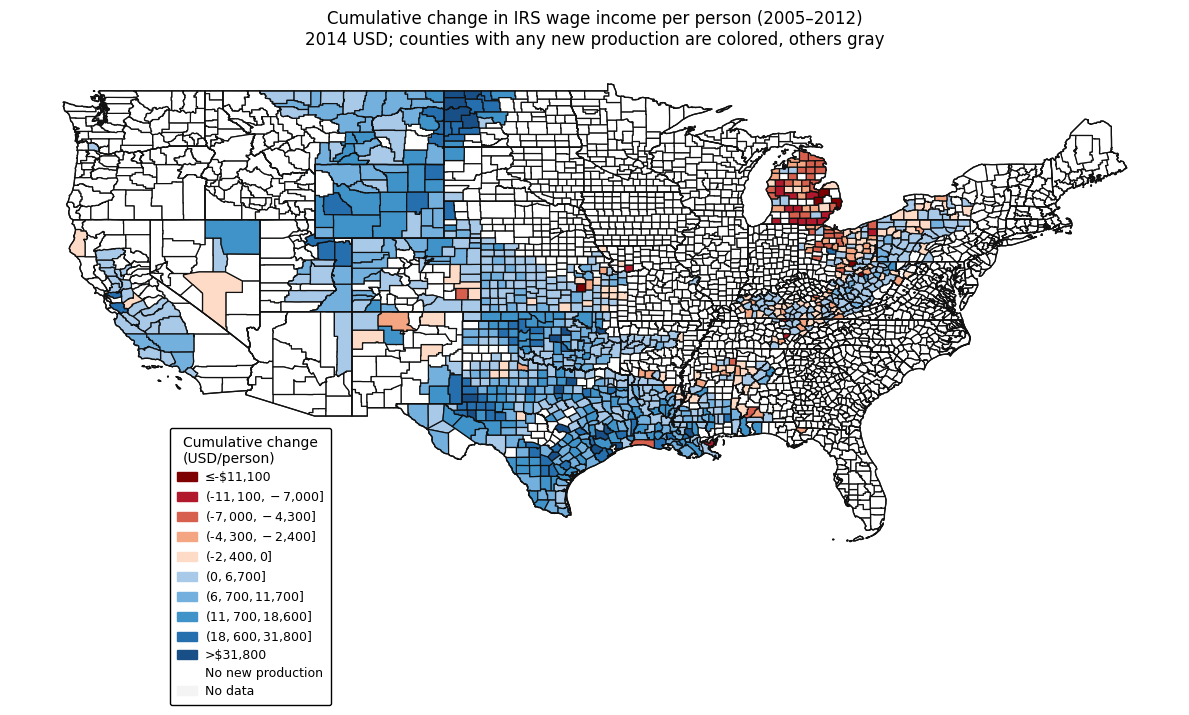

In [8]:
# Cumulative change in IRS wage income per person (2005–2012)
# • Colors only counties with ANY new production in 2005–2012 (others gray)
# • Bins are percentiles from the treated distribution, centered at $0
# • Dark county & state outlines to match your production map

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pandas.api.types import CategoricalDtype

# ---- Paths (edit to your machine) ----
PARQUET_PATH = "/Users/mickeynguyen/Documents/School /Fracking Paper/Data and Code/Parquet of Data/BLS_IRS_fossil_working.parquet"
COUNTY_SHP   = "/Users/mickeynguyen/Documents/School /Fracking Paper/Data and Code/cb_2018_us_county_5m/cb_2018_us_county_5m.shp"
WINDOW = (2005, 2012)

# ---------- 1) Load panel; build treated mask (any new production) ----------
df = pd.read_parquet(PARQUET_PATH)

prod = df.loc[df["year"].between(*WINDOW), ["fips", "year", "newvalue_capita"]].copy()
prod["newvalue_capita"] = pd.to_numeric(prod["newvalue_capita"], errors="coerce")
# keep one record per county–year to avoid duplicates, then mark counties with any positive production
prod_cy = prod.dropna(subset=["newvalue_capita"]).drop_duplicates(subset=["fips","year"])
treated = (prod_cy.assign(pos=prod_cy["newvalue_capita"] > 0)
                  .groupby("fips", as_index=False)["pos"].max()
                  .rename(columns={"pos":"any_production"}))
treated["fips5"] = treated["fips"].astype(str).str.zfill(5)

# ---------- 2) Build outcome: cumulative IRS wage-income change per person ----------
irs = df.loc[df["year"].between(*WINDOW), ["fips", "year", "d_irswages_capita"]].copy()
irs["d_irswages_capita"] = pd.to_numeric(irs["d_irswages_capita"], errors="coerce")
irs_cy = irs.dropna(subset=["d_irswages_capita"]).drop_duplicates(subset=["fips","year"])
cum_wage = (irs_cy.groupby("fips", as_index=False)["d_irswages_capita"].sum()
                 .rename(columns={"d_irswages_capita":"cum_d_irswages_capita_usd"}))
cum_wage["fips5"] = cum_wage["fips"].astype(str).str.zfill(5)

# ---------- 3) Read geometries (lower-48 + DC) and merge ----------
g = gpd.read_file(COUNTY_SHP)
DROP_STATES = {"02","15","72","60","66","69","78"}  # AK, HI, PR, island territories
g = g[~g["STATEFP"].isin(DROP_STATES)].copy()

g["GEOID"] = g["GEOID"].astype(str)
g = (g.merge(treated[["fips5","any_production"]], left_on="GEOID", right_on="fips5", how="left")
       .merge(cum_wage[["fips5","cum_d_irswages_capita_usd"]], on="fips5", how="left"))

# ---------- 4) Make percentile-based bins (treated counties only), centered at $0 ----------
treated_mask = g["any_production"].fillna(False)
val = g["cum_d_irswages_capita_usd"].astype(float)
v_treated = val[treated_mask & val.notna()]

# percentiles for positives and negatives separately (fallbacks if empty)
qpos = np.nanpercentile(v_treated[v_treated > 0], [50, 75, 90, 97.5]) if (v_treated > 0).any() else [250, 500, 1000, 2000]
qneg = np.nanpercentile(-v_treated[v_treated < 0], [50, 75, 90, 97.5]) if (v_treated < 0).any() else [250, 500, 1000, 2000]

# After computing qpos, qneg (arrays of percentiles):
qpos = np.round(np.array(qpos) / 100) * 100
qneg = np.round(np.array(qneg) / 100) * 100   # still magnitudes for negatives

def kfmt100(x):
    return f"{np.round(float(x)/100)*100:,.0f}"

edges = [-np.inf, -qneg[3], -qneg[2], -qneg[1], -qneg[0], 0.0,
          qpos[0],  qpos[1],  qpos[2],  qpos[3],  np.inf]

labels = [
    f"≤-${kfmt100(qneg[3])}",
    f"(-${kfmt100(qneg[3])}, -${kfmt100(qneg[2])}]",
    f"(-${kfmt100(qneg[2])}, -${kfmt100(qneg[1])}]",
    f"(-${kfmt100(qneg[1])}, -${kfmt100(qneg[0])}]",
    f"(-${kfmt100(qneg[0])}, $0]",
    f"($0, ${kfmt100(qpos[0])}]",
    f"(${kfmt100(qpos[0])}, ${kfmt100(qpos[1])}]",
    f"(${kfmt100(qpos[1])}, ${kfmt100(qpos[2])}]",
    f"(${kfmt100(qpos[2])}, ${kfmt100(qpos[3])}]",
    f">${kfmt100(qpos[3])}",
]

bin_series = pd.Series(index=g.index, dtype="object")
bin_series.loc[treated_mask] = pd.cut(val[treated_mask], bins=edges, labels=labels, right=True, include_lowest=True)
bin_series.loc[~treated_mask] = "No new production"
bin_series = bin_series.fillna("No data")

order = labels + ["No new production", "No data"]
g["bin_wage"] = bin_series.astype(CategoricalDtype(categories=order, ordered=True))

# ---------- 5) Colors (diverging: reds = losses, blues = gains) ----------
palette = dict(zip(labels, [
    "#7f0000", "#b2182b", "#d6604d", "#f4a582", "#fddbc7",  # losses: dark→light
    "#a8c9e8", "#74b0de", "#3f93c9", "#256fae", "#184f86"   # gains: light→dark
]))
palette.update({"No new production": "#ffffff", "No data": "#f4f4f5"})
g["__color_wage"] = g["bin_wage"].map(palette)

# ---------- 6) Plot ----------
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# counties (filled) with dark outlines
g.plot(ax=ax, color=g["__color_wage"], edgecolor="#111111", linewidth=0.9, zorder=1)

# state outlines on top
states = g.dissolve(by="STATEFP", as_index=False)[["STATEFP","geometry"]]
states.boundary.plot(ax=ax, edgecolor="#111111", linewidth=0.9, zorder=2)

ax.set_aspect("equal"); ax.set_axis_off()
ax.set_title("Cumulative change in IRS wage income per person (2005–2012)\n"
             "2014 USD; counties with any new production are colored, others gray", pad=12)

handles = [mpatches.Patch(color=palette[c], label=c) for c in order]

ca = g[g["STATEFP"] == "06"].total_bounds  # minx, miny, maxx, maxy
x_mid = (ca[0] + ca[2]) / 2
y_below = ca[1] - 1.5   # a little below CA (degrees; adjust as needed)

ax.legend(
    handles=handles, title="Cumulative change\n(USD/person)",
    loc="upper left",
    bbox_to_anchor=(x_mid, y_below),
    bbox_transform=ax.transData,      # <-- interpret anchor in map coords
    frameon=True, facecolor="white", edgecolor="black", framealpha=1.0,
    fontsize=9, title_fontsize=10, borderpad=0.6, labelspacing=0.4,
    handlelength=1.6, handletextpad=0.6
)

plt.tight_layout(); plt.show()


/var/folders/jz/f_xwhp0d6b9bslqfq_83rz6m0000gn/T/ipykernel_291/2984041572.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  treated_mask = g["any_production"].fillna(False)


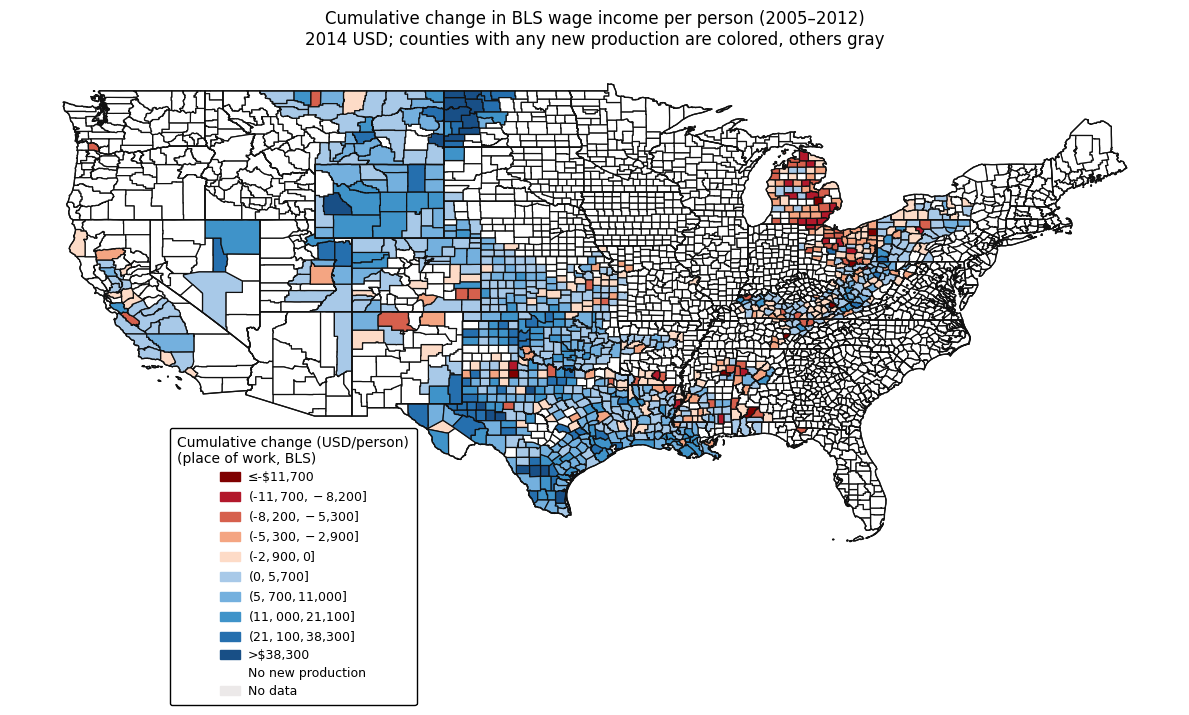

In [9]:
# Cumulative change in BLS wage income per person (2005–2012), treated-only map
# • Treated = counties with any new production in 2005–2012
# • Diverging bins from treated percentiles, centered at $0, rounded to nearest $100
# • Dark county & state outlines; legend tucked below California

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pandas.api.types import CategoricalDtype

# ---- Paths ----
PARQUET_PATH = "/Users/mickeynguyen/Documents/School /Fracking Paper/Data and Code/Parquet of Data/BLS_IRS_fossil_working.parquet"
COUNTY_SHP   = "/Users/mickeynguyen/Documents/School /Fracking Paper/Data and Code/cb_2018_us_county_5m/cb_2018_us_county_5m.shp"
WINDOW = (2005, 2012)

# ---------- 1) Treated mask (any new production, 2005–2012) ----------
df = pd.read_parquet(PARQUET_PATH)

prod = df.loc[df["year"].between(*WINDOW), ["fips","year","newvalue_capita"]].copy()
prod["newvalue_capita"] = pd.to_numeric(prod["newvalue_capita"], errors="coerce")
prod_cy = prod.dropna(subset=["newvalue_capita"]).drop_duplicates(subset=["fips","year"])
treated = (prod_cy.assign(pos=prod_cy["newvalue_capita"] > 0)
                 .groupby("fips", as_index=False)["pos"].max()
                 .rename(columns={"pos":"any_production"}))
treated["fips5"] = treated["fips"].astype(str).str.zfill(5)

# ---------- 2) Outcome: cumulative BLS wage change per person ----------
bls = df.loc[df["year"].between(*WINDOW), ["fips","year","d_wages_capita"]].copy()
bls["d_wages_capita"] = pd.to_numeric(bls["d_wages_capita"], errors="coerce")
bls_cy = bls.dropna(subset=["d_wages_capita"]).drop_duplicates(subset=["fips","year"])
cum_bls = (bls_cy.groupby("fips", as_index=False)["d_wages_capita"].sum()
                .rename(columns={"d_wages_capita":"cum_d_blswages_capita_usd"}))
cum_bls["fips5"] = cum_bls["fips"].astype(str).str.zfill(5)

# ---------- 3) Geometry + merges (lower-48 + DC) ----------
g = gpd.read_file(COUNTY_SHP)
DROP_STATES = {"02","15","72","60","66","69","78"}
g = g[~g["STATEFP"].isin(DROP_STATES)].copy()
g["GEOID"] = g["GEOID"].astype(str)
g = (g.merge(treated[["fips5","any_production"]], left_on="GEOID", right_on="fips5", how="left")
       .merge(cum_bls[["fips5","cum_d_blswages_capita_usd"]], on="fips5", how="left"))

# ---------- 4) Percentile bins (treated-only), center at $0 ----------
treated_mask = g["any_production"].fillna(False)
val = g["cum_d_blswages_capita_usd"].astype(float)
v_treated = val[treated_mask & val.notna()]

# Percentiles; round to nearest $100 for cleaner labels (and edges)
qpos = np.nanpercentile(v_treated[v_treated > 0], [50, 75, 90, 97.5]) if (v_treated > 0).any() else [250, 500, 1000, 2000]
qneg = np.nanpercentile(-v_treated[v_treated < 0], [50, 75, 90, 97.5]) if (v_treated < 0).any() else [250, 500, 1000, 2000]
qpos = np.round(np.array(qpos)/100)*100
qneg = np.round(np.array(qneg)/100)*100

def fmt100(x):  # $ with thousands, nearest $100
    return f"{np.round(float(x)/100)*100:,.0f}"

edges = [-np.inf, -qneg[3], -qneg[2], -qneg[1], -qneg[0], 0.0,
          qpos[0],  qpos[1],  qpos[2],  qpos[3],  np.inf]

labels = [
    f"≤-${fmt100(qneg[3])}",
    f"(-${fmt100(qneg[3])}, -${fmt100(qneg[2])}]",
    f"(-${fmt100(qneg[2])}, -${fmt100(qneg[1])}]",
    f"(-${fmt100(qneg[1])}, -${fmt100(qneg[0])}]",
    f"(-${fmt100(qneg[0])}, $0]",
    f"($0, ${fmt100(qpos[0])}]",
    f"(${fmt100(qpos[0])}, ${fmt100(qpos[1])}]",
    f"(${fmt100(qpos[1])}, ${fmt100(qpos[2])}]",
    f"(${fmt100(qpos[2])}, ${fmt100(qpos[3])}]",
    f">${fmt100(qpos[3])}",
]

bin_series = pd.Series(index=g.index, dtype="object")
bin_series.loc[treated_mask] = pd.cut(val[treated_mask], bins=edges, labels=labels,
                                      right=True, include_lowest=True)
bin_series.loc[~treated_mask] = "No new production"
bin_series = bin_series.fillna("No data")
order = labels + ["No new production", "No data"]
g["bin_bls"] = bin_series.astype(CategoricalDtype(categories=order, ordered=True))

# ---------- 5) Palette (darker positives, to match fracking map intensity) ----------
neg_colors = ["#7f0000", "#b2182b", "#d6604d", "#f4a582", "#fddbc7"]
pos_colors = ["#a8c9e8", "#74b0de", "#3f93c9", "#256fae", "#184f86"]
palette = dict(zip(labels, neg_colors + pos_colors))
palette.update({"No new production": "#ffffff", "No data": "#ece9e9"})
g["__color_bls"] = g["bin_bls"].map(palette)

# ---------- 6) Plot ----------
fig, ax = plt.subplots(1, 1, figsize=(12, 7))
g.plot(ax=ax, color=g["__color_bls"], edgecolor="#111111", linewidth=0.9, zorder=1)
states = g.dissolve(by="STATEFP", as_index=False)[["STATEFP","geometry"]]
states.boundary.plot(ax=ax, edgecolor="#111111", linewidth=0.9, zorder=2)

ax.set_aspect("equal"); ax.set_axis_off()
ax.set_title("Cumulative change in BLS wage income per person (2005–2012)\n"
             "2014 USD; counties with any new production are colored, others gray", pad=12)

# Legend anchored below California
handles = [mpatches.Patch(color=palette[c], label=c) for c in order]
minx, miny, maxx, maxy = g[g["STATEFP"]=="06"].total_bounds
x_anchor = (minx + maxx) / 2
y_anchor = miny - 1.5

ax.legend(handles=handles, title="Cumulative change (USD/person)\n(place of work, BLS)",
          loc="upper left", bbox_to_anchor=(x_anchor, y_anchor), bbox_transform=ax.transData,
          frameon=True, facecolor="white", edgecolor="black", framealpha=1.0,
          fontsize=9, title_fontsize=10, borderpad=0.6, labelspacing=0.4,
          handlelength=1.6, handletextpad=0.6)

plt.tight_layout(); plt.show()
